<a href="https://colab.research.google.com/github/jorgedata01/ESPY_G5/blob/main/Tarea_1_Machine_Learning_Jorge_%C3%81lvarez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Tarea 1 - Machine Learning | Jorge Álvarez**
---

##**1. Carga y exploración inicial de los datos**

•	Importar el dataset

•	Visualizar las primeras filas

•	Revisar la estructura del dataset

•	Verificar si existen valores nulos

•	Obtener estadísticas descriptivas básicas


In [ ]:
#Linkeamos con el Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Tratamiento de datos
import pandas as pd
import numpy as np

# Gráficos
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Estadística
from scipy import stats
from scipy.stats import pearsonr

# Modelos
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

# Configuración visual
plt.rcParams['image.cmap']   = 'bwr'
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['figure.dpi']   = 100
style.use('ggplot')

# Ignorar advertencias ← agregar aquí
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Cargamos el dataset y visualizamos las primeras 5 filas

df = pd.read_csv('/content/drive/MyDrive/dataset_marketing_ventas.csv')


df.head()

,inversion_tv,inversion_radio,inversion_redes_sociales,inversion_periodico,ventas
0,93.49,33.43,74.16,24.40,50.40
1,99.80,40.86,89.91,26.03,42.57
2,87.41,41.63,77.81,30.89,40.24
3,136.14,61.82,113.05,43.43,58.63
4,164.64,86.94,151.48,52.44,77.16


In [ ]:
# Contamos la cantidad de filas y columnas

df.shape

(10000, 5)

In [ ]:
# Chequeamos el tipo de datos

df.dtypes

inversion_tv                float64
inversion_radio             float64
inversion_redes_sociales    float64
inversion_periodico         float64
ventas                      float64
dtype: object

In [ ]:
# Chequeamos si existen valores nulos por columna

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   inversion_tv              10000 non-null  float64
 1   inversion_radio           10000 non-null  float64
 2   inversion_redes_sociales  10000 non-null  float64
 3   inversion_periodico       10000 non-null  float64
 4   ventas                    10000 non-null  float64
dtypes: float64(5)
memory usage: 390.8 KB


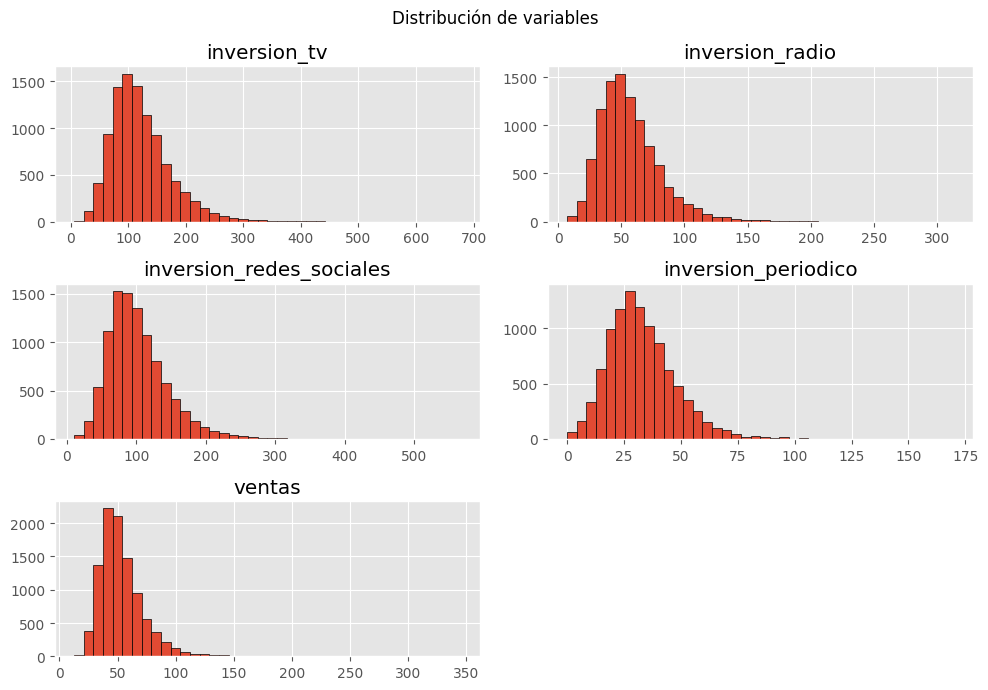

In [ ]:
# Graficamos el histograma de cada variable para visualizar sus distribuciones

df.hist(figsize=(10, 7), bins=40, edgecolor='black')
plt.suptitle('Distribución de variables')
plt.tight_layout()
plt.show()

In [ ]:
plt.rcParams['image.cmap'] = 'bwr'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.bbox'] = 'tight'
style.use('ggplot') or plt.style.use('ggplot')

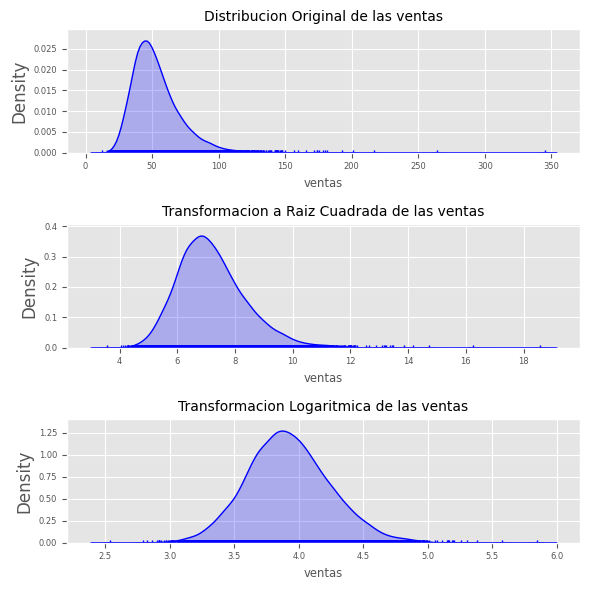

In [ ]:
fig, axes = plt.subplots(nrows = 3, ncols= 1,figsize=(6, 6))

sns.distplot(
    df['ventas'],
    hist = False,
    rug = True,
    color= 'blue',
    kde_kws= {'shade': True, 'linewidth':1},
    ax = axes[0])

axes[0].set_title('Distribucion Original de las ventas', fontsize = 'medium')
axes[0].set_xlabel('ventas', fontsize = 'small')
axes[0].tick_params(labelsize = 6)

#################

sns.distplot(
    np.sqrt(df['ventas']),
    hist = False,
    rug = True,
    color= 'blue',
    kde_kws= {'shade': True, 'linewidth':1},
    ax = axes[1])

axes[1].set_title('Transformacion a Raiz Cuadrada de las ventas', fontsize = 'medium')
axes[1].set_xlabel('ventas', fontsize = 'small')
axes[1].tick_params(labelsize = 6)

#################

sns.distplot(
    np.log(df['ventas']),
    hist = False,
    rug = True,
    color= 'blue',
    kde_kws= {'shade': True, 'linewidth':1},
    ax = axes[2])

axes[2].set_title('Transformacion Logaritmica de las ventas', fontsize = 'medium')
axes[2].set_xlabel('ventas', fontsize = 'small')
axes[2].tick_params(labelsize = 6)

fig.tight_layout()
plt.show()

In [ ]:
# Análisis de distribución estadística de la variable objetivo

# ── Instalación (ejecutar solo una vez en Colab) ─────────────
!pip install fitter --quiet

from fitter import Fitter, get_common_distributions

# Obtener todas las distribuciones más comunes del paquete fitter
todas_las_distribuciones = get_common_distributions()

# Crear el objeto Fitter con todas las distribuciones
fitter = Fitter(df.ventas, distributions=todas_las_distribuciones)

# Ajustar los datos
fitter.fit()

# Mostrar el resumen de las N mejores distribuciones
resultados = fitter.summary(Nbest=len(todas_las_distribuciones), plot=False)

# Mostrar las mejores 5 distribuciones según el AIC
# (entre menor valor, mejor es el ajuste)
mejores_distribuciones = resultados.sort_values(by='aic').head(5)

mejores_distribuciones

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
lognorm,0.000019,84422.056295,84443.687316,0.007840,0.014454,3.035383e-02
rayleigh,0.000500,86276.585469,86291.006149,0.134107,0.100194,7.613807e-88
norm,0.000534,87497.606603,87512.027284,0.129123,0.093575,1.178329e-76
cauchy,0.000409,87926.098649,87940.519329,0.280666,0.110298,2.061637e-106
expon,0.003265,94101.181937,94115.602617,1.343186,0.306245,0.000000e+00


In [ ]:
# Revisamos las principales medidas de tendencia central del dataset:

df.describe().round(1)

,inversion_tv,inversion_radio,inversion_redes_sociales,inversion_periodico,ventas
count,10000.0,10000.0,10000.0,10000.0,10000.0
mean,121.4,56.7,102.6,32.8,53.3
std,51.8,24.1,43.4,15.1,19.2
min,5.9,7.2,10.9,0.0,12.7
25%,85.2,40.0,72.4,22.5,40.4
50%,112.2,52.6,94.9,30.8,49.6
75%,147.7,68.9,124.2,41.0,61.9
max,677.0,312.6,566.1,169.7,344.8


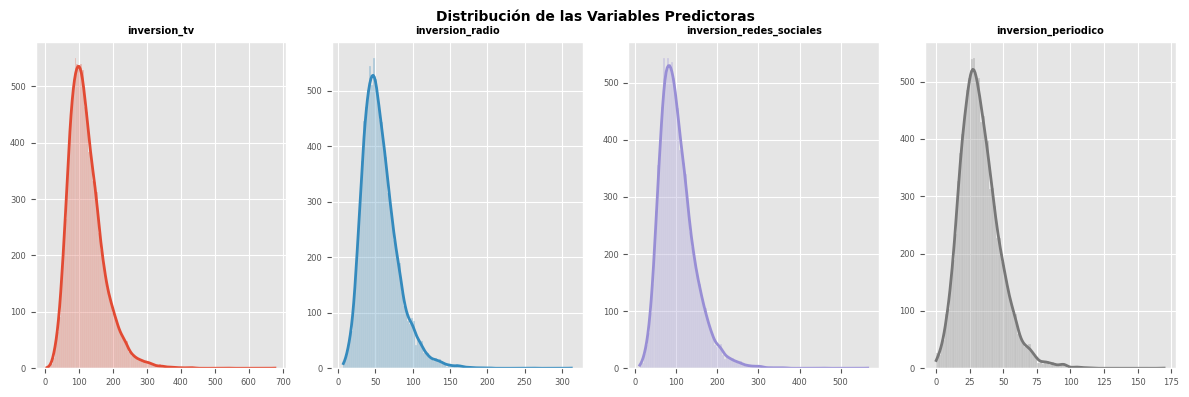

In [ ]:
# Graficamos la distribución de las Variables Predictoras

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 4))
axes = axes.flat

columnas_numericas = df.select_dtypes(include=np.number).columns
columnas_numericas = columnas_numericas.drop('ventas')

for i, columna in enumerate(columnas_numericas):
    sns.histplot(
        data     = df,
        x        = columna,
        stat     = 'count',
        kde      = True,
        color    = list(plt.rcParams['axes.prop_cycle'] * 2)[i]['color'],
        line_kws = {'linewidth': 2},
        alpha    = 0.3,
        ax       = axes[i]
    )
    axes[i].set_title(columna, fontsize=7, fontweight='bold')
    axes[i].tick_params(labelsize=6)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

fig.tight_layout()
plt.subplots_adjust(top=0.9)
plt.suptitle('Distribución de las Variables Predictoras',
             fontsize='medium', fontweight='bold')
plt.show()

##**2. Análisis de correlación**

Calcular la matriz de correlación entre las variables.

Identificar:

•	Variables tienen mayor relación con ventas

•	Sí existe relación entre las variables predictoras



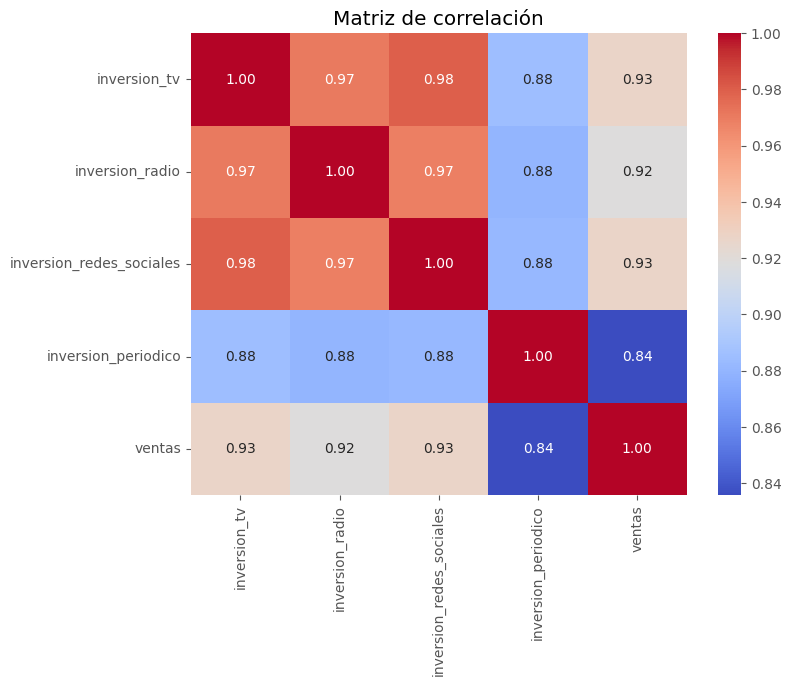

In [ ]:
# Mapa de calor: Correlación de Pearson

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

In [ ]:
# Variables con mayor relación con la etiqueta "ventas"

def matriz_correlacion(corr_mat):
    """Convierte la matriz de correlación a formato tabular ordenado."""
    corr_mat = corr_mat.stack().reset_index()
    corr_mat.columns = ['variable_1', 'variable_2', 'correlacion']
    corr_mat = corr_mat.loc[corr_mat['variable_1'] != corr_mat['variable_2'], :]
    corr_mat['Valor Absoluto'] = np.abs(corr_mat['correlacion'])
    corr_mat = corr_mat.sort_values('Valor Absoluto', ascending=False)
    return corr_mat

corr_matrix = df.select_dtypes(include=['float', 'int']).corr(method='pearson')

# Filtramos solo las correlaciones con 'ventas'
corr_con_ventas = (
    matriz_correlacion(corr_matrix)
    .query("variable_1 == 'ventas' or variable_2 == 'ventas'")
    .query("variable_1 != variable_2")
    .drop_duplicates(subset='Valor Absoluto')
    .reset_index(drop=True)
)

print("Correlación de cada variable con 'ventas' (ordenada):")
corr_con_ventas

Correlación de cada variable con 'ventas' (ordenada):


,variable_1,variable_2,correlacion,Valor Absoluto
0,ventas,inversion_tv,0.927440,0.927440
1,ventas,inversion_redes_sociales,0.927031,0.927031
2,ventas,inversion_radio,0.918294,0.918294
3,inversion_periodico,ventas,0.835763,0.835763


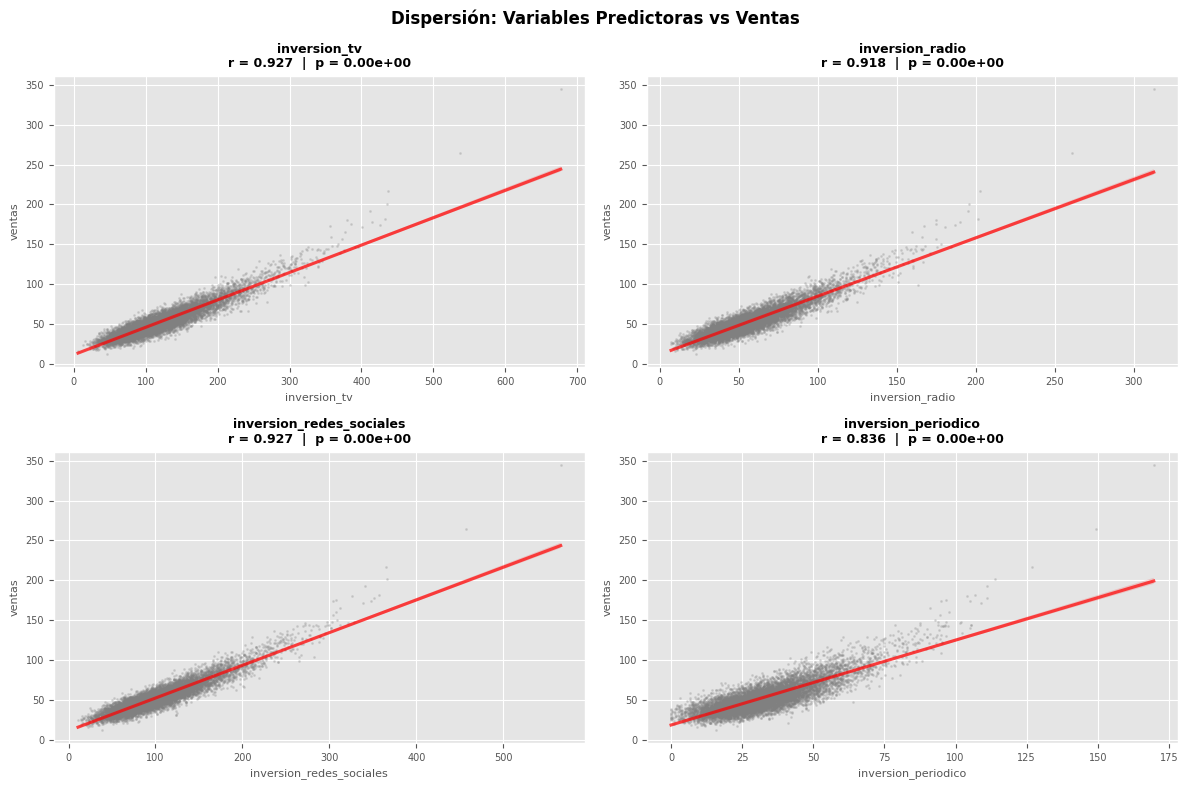

In [ ]:
# Graficamos la dispersión de las Variables Predictoras, en relación con la Variable a predecir: "ventas"

features = ['inversion_tv', 'inversion_radio',
            'inversion_redes_sociales', 'inversion_periodico']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), features):
    r, p = pearsonr(df[col], df['ventas'])

    sns.regplot(
        data        = df,
        x           = col,
        y           = 'ventas',
        color       = 'gray',
        marker      = '.',
        scatter_kws = {'alpha': 0.2, 's': 5},
        line_kws    = {'color': 'red', 'alpha': 0.7},
        ax          = ax
    )
    ax.set_title(f'{col}\nr = {r:.3f}  |  p = {p:.2e}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('ventas', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle('Dispersión: Variables Predictoras vs Ventas',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


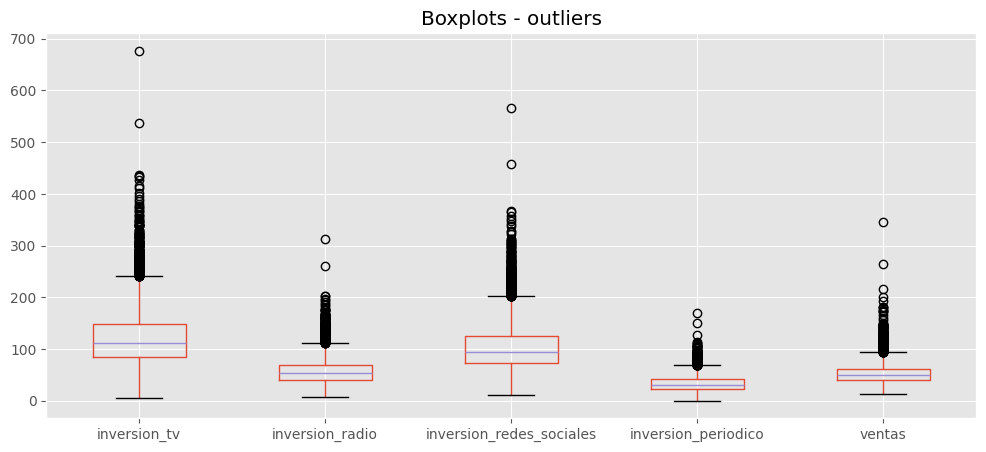

In [ ]:
# Boxplots para detectar outliers

df.boxplot(figsize=(12, 5))
plt.title('Boxplots - outliers')
plt.show()

#**Nota del Analista:**
---

A pesar que aparentemente existe un número importante de OUTLIERS, por conocimiento y experiencia en el manejo de Análisis publicitario y de Medios de comunicación, es práctica común de la industria trabajar las campañas con un lanzamiento inicial de inversiones grandes para luego ir disminuyendo la inversion en la etapa de mantenimiento.

En publicidad, lo que se compra es: "*espacio, por un período de tiempo*" para exponer el mensaje a comunicar.

Y, con esta estrategia se busca, con una inversión inicial grande, que el contenido y el mensaje sean conocidos por la mayoría de su audiencia objetivo (tarjet), lo que se mide con una variable llamada *Frecuencia* la que debe llegar a una cifra estandarizada: +3, lo que implica que en promedio, su tarjet debe ver la publicidad al menos 3 veces, de modo que la conozca y algo del mensaje se fije en su memoria. Esta es a etapa que cuesta más porqe debe repetirse mucho la pieza publicitaria, para cumplir el objetivo.

Luego de un tiempo prudencial, y cuando se llega o se acerca a la Frecuencia +3, se comienza a disminuir tanto el tamaño de espacio comprado, como el tiempo de exposición (pasando de spot de 30" a uno de 20", y hasta de 15" o 10", lo mismo en radio, prensa y Redes Sociales), parando de inversiones grandes a inversiones progresivamente mínimas.

Eso genera las gráficas con ese comportamiento característico, que aparentan ser valores "anormales", cuando es un estándard muy usual.

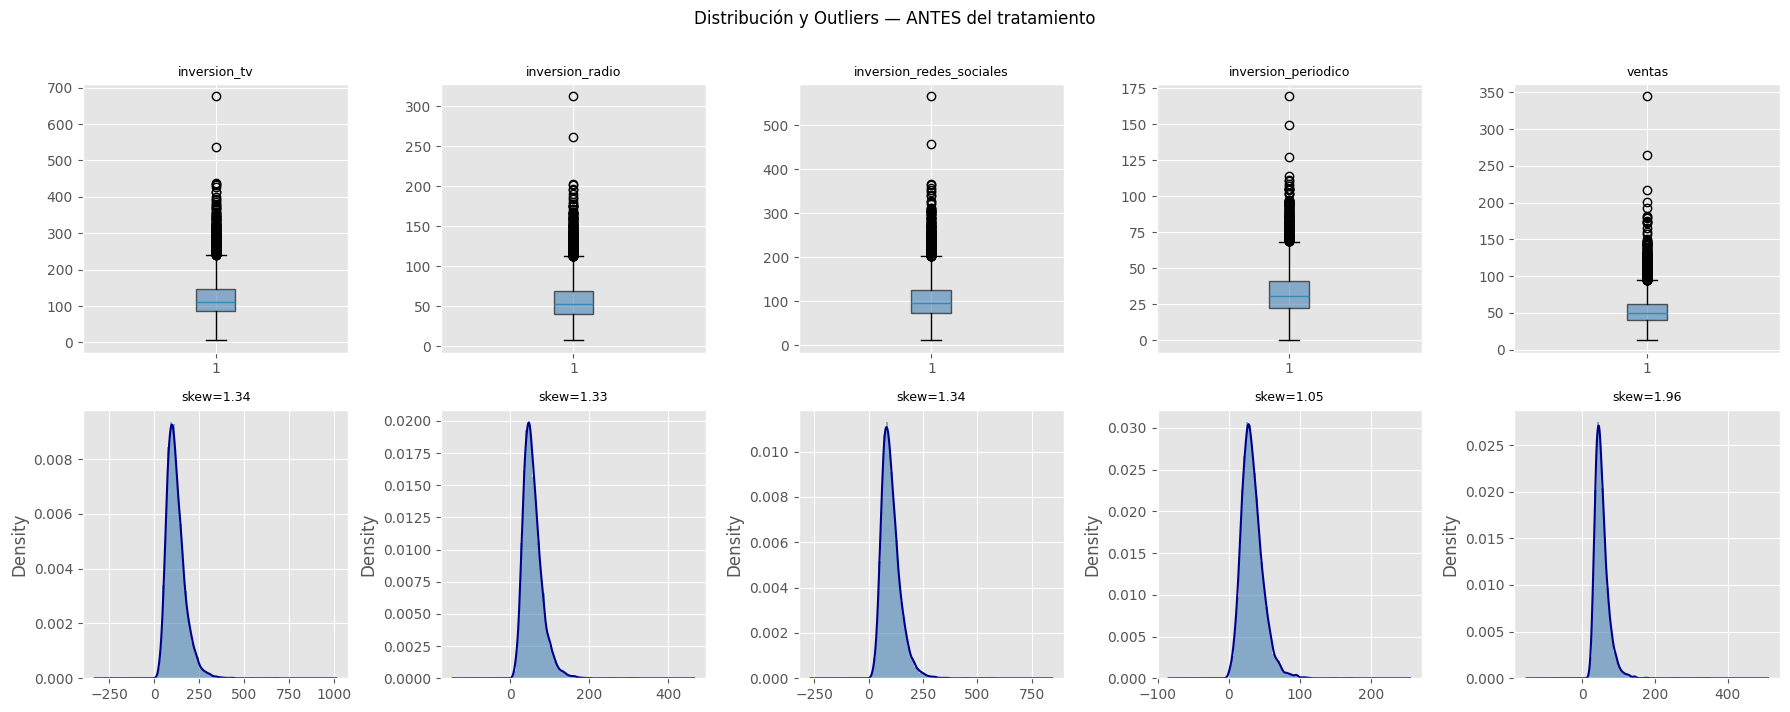

In [ ]:
 # Visualización de la Distribución, Skewness, y los Ouliers

 """
 La asimetría (skewness) mide la falta de simetría en una distribución de datos.
 Un valor de 0 indica una distribución simétrica (normal).
 Un valor positivo (>0) indica una cola más larga a la derecha (sesgo a la derecha),
 mientras que un valor negativo (<0) indica una cola más larga a la izquierda
 (sesgo a la izquierda)
 """

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i, col in enumerate(df.columns):
    # Boxplot
    axes[0, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[0, i].set_title(col, fontsize=9)
    # Histograma con KDE
    axes[1, i].hist(df[col], bins=50, color='steelblue', alpha=0.6, density=True)
    df[col].plot.kde(ax=axes[1, i], color='darkblue')
    axes[1, i].set_title(f'skew={df[col].skew():.2f}', fontsize=9)
plt.suptitle('Distribución y Outliers — ANTES del tratamiento', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Adaptamos las variables X e y a nuestro dataset.

X = df.drop(columns='ventas')
y = df['ventas']

print("Variables independientes (X):")
print(f"  Columnas : {X.columns.tolist()}")
print(f"  Shape    : {X.shape}")
print("\nVariable dependiente (y):")
print(f"  Nombre   : {y.name}")
print(f"  Shape    : {y.shape}")

Variables independientes (X):
  Columnas : ['inversion_tv', 'inversion_radio', 'inversion_redes_sociales', 'inversion_periodico']
  Shape    : (10000, 4)

Variable dependiente (y):
  Nombre   : ventas
  Shape    : (10000,)


In [ ]:
# Correlación entre Variables Numéricas

def matriz_correlacion(corr_mat):
    """Función para convertir una matriz de correlación a formato tipo DataFrame."""
    corr_mat = corr_mat.stack().reset_index()
    corr_mat.columns = ['variable_1', 'variable_2', 'correlacion']
    corr_mat = corr_mat.loc[corr_mat['variable_1'] != corr_mat['variable_2'], :]
    corr_mat['Absoluto'] = np.abs(corr_mat['correlacion'])
    corr_mat = corr_mat.sort_values('Absoluto', ascending=False)
    return corr_mat

corr_matrix = df.select_dtypes(include=['float', 'int']).corr(method='pearson')
matriz_correlacion(corr_matrix).head(10)

,variable_1,variable_2,correlacion,Absoluto
2,inversion_tv,inversion_redes_sociales,0.979911,0.979911
10,inversion_redes_sociales,inversion_tv,0.979911,0.979911
5,inversion_radio,inversion_tv,0.970747,0.970747
1,inversion_tv,inversion_radio,0.970747,0.970747
11,inversion_redes_sociales,inversion_radio,0.968966,0.968966
7,inversion_radio,inversion_redes_sociales,0.968966,0.968966
20,ventas,inversion_tv,0.927440,0.927440
4,inversion_tv,ventas,0.927440,0.927440
22,ventas,inversion_redes_sociales,0.927031,0.927031
14,inversion_redes_sociales,ventas,0.927031,0.927031


##**3. Definición de variables predictoras y variable objetivo**

Separar el dataset en:



*   Variables independientes (X)

*   Variable dependiente (y)


In [ ]:
# División del dataset: 80% Train y 20% Test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.values.reshape(-1, 1),
    test_size    = 0.2,
    random_state = 1234,
    shuffle      = True
)

# Verificación
print('Resultado de la Partición de los Datos')
print('---------------------------------------')
print(f'  X_train : {X_train.shape}  →  {X_train.shape[0]:,} observaciones de entrenamiento')
print(f'  X_test  : {X_test.shape}   →  {X_test.shape[0]:,} observaciones de prueba')
print(f'  y_train : {y_train.shape}')
print(f'  y_test  : {y_test.shape}')
print('---------------------------------------')
print(f'  Train   : {X_train.shape[0]/len(X)*100:.0f}%')
print(f'  Test    : {X_test.shape[0]/len(X)*100:.0f}%')


Resultado de la Partición de los Datos
---------------------------------------
  X_train : (8000, 4)  →  8,000 observaciones de entrenamiento
  X_test  : (2000, 4)   →  2,000 observaciones de prueba
  y_train : (8000, 1)
  y_test  : (2000, 1)
---------------------------------------
  Train   : 80%
  Test    : 20%


##**4. División del dataset**

Dividir el dataset en:

•	Training set

•	Test set

In [ ]:
# División del dataset — Training set y Test set

from sklearn.model_selection import train_test_split

# ── Cambio 1: 'datos' → 'df'
# ── Cambio 2: 'ventas' → 'ventas'

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('ventas', axis='columns'),
    df.ventas,
    train_size   = 0.8,
    test_size    = 0.2,
    random_state = 42,
    shuffle      = True
)

print('Resultado de la Partición de los Datos de Entrenamiento')
print('--------------------------------------------------------')
print(y_train.describe())
print()
print('Resultado de la Partición de los Datos de Prueba')
print('--------------------------------------------------------')
print(y_test.describe())


Resultado de la Partición de los Datos de Entrenamiento
--------------------------------------------------------
count    8000.000000
mean       53.326106
std        19.378634
min        12.660000
25%        40.410000
50%        49.585000
75%        61.725000
max       344.810000
Name: ventas, dtype: float64

Resultado de la Partición de los Datos de Prueba
--------------------------------------------------------
count    2000.000000
mean       53.217175
std        18.560512
min        16.860000
25%        40.217500
50%        49.670000
75%        62.540000
max       180.260000
Name: ventas, dtype: float64


##**5. Implementación de modelos lineales**

Entrenar los siguientes modelos:

•	Regresión Lineal

•	Ridge Regression

•	Lasso Regression

•	Elastic Net


####**5.1. Regresión Lineal (OLS)**


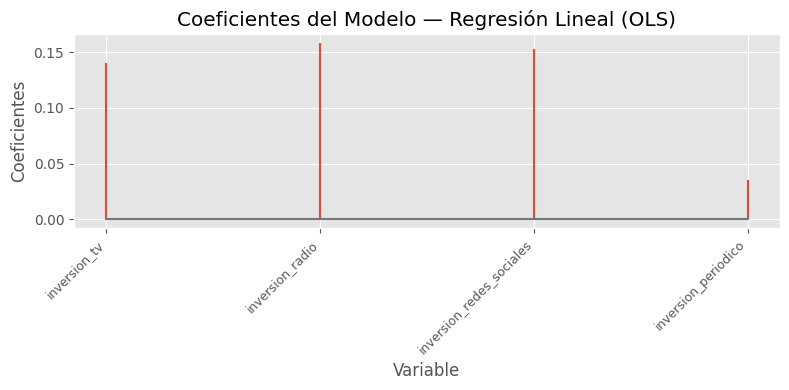

               predictor     coef
            inversion_tv 0.140226
         inversion_radio 0.157973
inversion_redes_sociales 0.152829
     inversion_periodico 0.034920

  Intercepto : 10.5387
── Regresión Lineal (OLS) ──────────────────────
  R²   = 0.8707
  MAE  = 5.3352
  RMSE = 6.6734


In [ ]:
# 5.1 REGRESIÓN LINEAL (OLS)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ── Crear y entrenar el modelo ───────────────────────────────

modelo_ols = LinearRegression()
modelo_ols.fit(X=X_train, y=y_train)

# ── Coeficientes del modelo ──────────────────────────────────

df_coeficientes = pd.DataFrame({
    'predictor' : X_train.columns,
    'coef'      : modelo_ols.coef_.flatten()
})

fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=45, ha='right', size=9)
ax.set_ylabel('Coeficientes')
ax.set_xlabel('Variable')
ax.set_title('Coeficientes del Modelo — Regresión Lineal (OLS)')
plt.tight_layout()
plt.show()

print(df_coeficientes.to_string(index=False))
print(f"\n  Intercepto : {modelo_ols.intercept_:.4f}")

# ── Predicciones del test ────────────────────────────────────

pred_ols = modelo_ols.predict(X=X_test).flatten()
pred_ols[:10]

# ── Métricas de evaluación ───────────────────────────────────

r2_ols   = r2_score(y_true=y_test, y_pred=pred_ols)
mae_ols  = mean_absolute_error(y_true=y_test, y_pred=pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y_true=y_test, y_pred=pred_ols))

print("── Regresión Lineal (OLS) ──────────────────────")
print(f"  R²   = {r2_ols:.4f}")
print(f"  MAE  = {mae_ols:.4f}")
print(f"  RMSE = {rmse_ols:.4f}")

In [ ]:
# Predicciones del test

pred_ols = modelo_ols.predict(X=X_test)
pred_ols = pred_ols.flatten()
pred_ols[:10]

array([ 65.30984719,  39.69031748, 117.41112802,  59.83162075,
        51.96421024,  41.63946662,  49.55667821,  33.91403817,
        28.5435852 ,  40.80656655])

In [ ]:
from sklearn.metrics import r2_score

r2_ols = r2_score(
    y_true = y_test,
    y_pred = pred_ols)

print(f'El coeficiente de determinación del test es: {r2_ols}')

El coeficiente de determinación del test es: 0.8706618016082219


#**Nota del Analista:**
---

Lo que nos dice la REGRESIÓN LINEAL es que:

1.   Radio (0.158), Redes Sociales (0.153), y TV (0.140) son los predictores más importantes.  Esto implica que, por cada unidad adicional invertida en radio, las ventas suben ~0.158 unidades, manteniendo las demás constantes. TV y Redes Sociales tienen un efecto casi igual.

2.   Periódico tiene impacto marginal (0.035), es 4 a 5 veces menor que los otros tres. Invertir en periódico genera muy poco retorno en ventas comparado con los otros canales. Es el predictor menos relevante del modelo.

3.   Señal de multicolinealidad. Los coeficientes de TV, Radio y Redes Sociales son casi idénticos a pesar de que en los scatter plots TV tenía la correlación más alta con ventas (r=0.927). Esto es efecto directo de la multicolinealidad alta que detectamos en el Paso 2, donde vimos que los predictores están muy correlacionados entre sí (r > 0.87), OLS distribuye el peso entre ellos de forma imprecisa.

4.   Esto justifica el uso de Ridge, Lasso y Elastic-Net en los siguientes modelos. La regularización maneja mejor este problema.



5.   R² = 0.8707, implica un Modelo con buen poder predictivo. Las 4 variables de inversión en marketing explican muy bien las ventas. Un R² > 0.80 en contexto de marketing explica un modelo sólido.

6.   MAE = 5.33 — Error promedio manejable. Considerando que la media de ventas es 53.30 y el MAE es 5.33, el error relativo promedio es aproximadamente: 5.33 / 53.30 ≈ 1% de error promedio.



7.   RMSE > MAE — Presencia de errores grandes. El RMSE (6.67) es bastante mayor que el MAE (5.33). Dado que el RMSE penaliza errores grandes, esta diferencia confirma lo que vimos en los boxplots: Los outliers están afectando algunas predicciones puntuales.



8.   Se espera que Ridge, Lasso y Elastic-Net, deberían mejorar estos valores, especialmente el RMSE, porque su regularización reduce el impacto de la multicolinealidad y los outliers que OLS no maneja. Si los valores son muy similares, significará que la relación es esencialmente lineal y la regularización no aporta mucho en este dataset.















####**5.2. Ridge Regression**


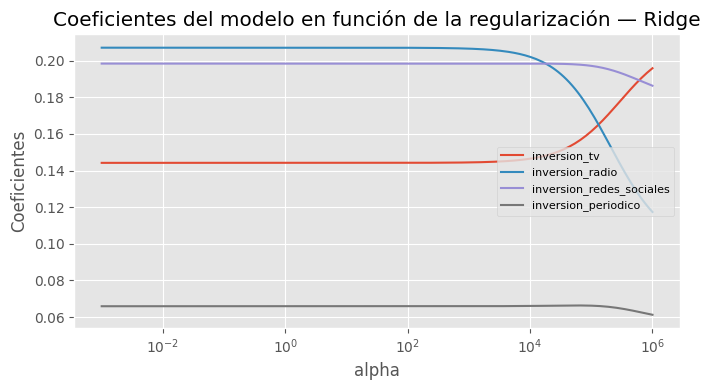

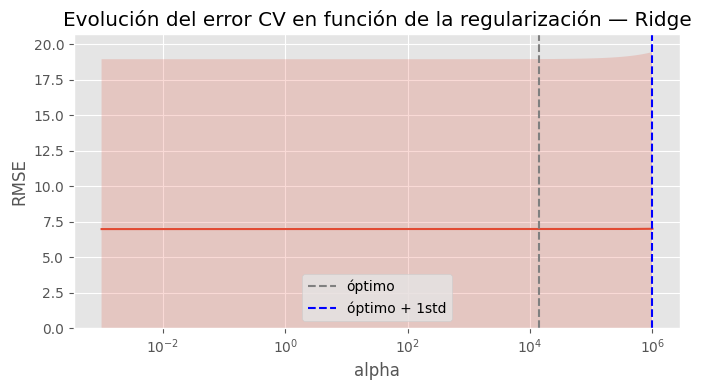

Mejor valor de alpha encontrado: 13987.131026472387


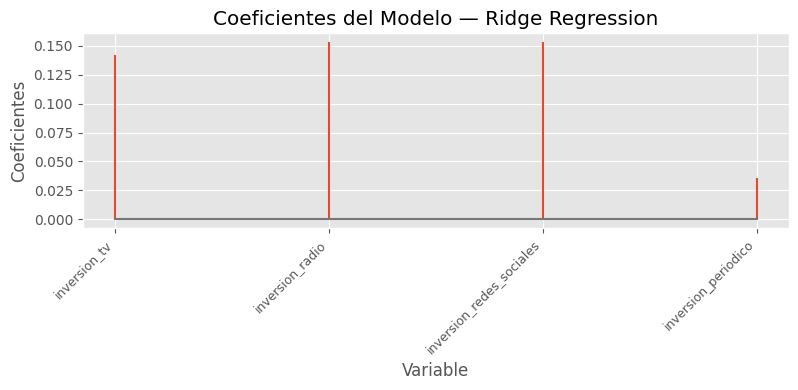

               predictor     coef
            inversion_tv 0.141973
         inversion_radio 0.152988
inversion_redes_sociales 0.153094
     inversion_periodico 0.035693
── Ridge Regression ────────────────────────────
  Mejor alpha : 13987.131026
  R²          = 0.8707
  MAE         = 5.3356
  RMSE        = 6.6727


In [ ]:
# 5.2 RIDGE REGRESSION

from sklearn.linear_model import Ridge, RidgeCV

N_ALPHAS = 200  # constante para reusar en reshape y loop

# Crear y entrenar el modelo (búsqueda del alpha óptimo por CV)

modelo_ridge = RidgeCV(
    alphas          = np.logspace(-3, 6, N_ALPHAS),  # ← rango ampliado
    fit_intercept   = True,
    store_cv_values = True
)

_ = modelo_ridge.fit(X=X_train, y=y_train)

# Evolución de coeficientes en función del alpha

alphas = modelo_ridge.alphas

coefs = []
for alpha in alphas:
    modelo_temp = Ridge(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_title('Coeficientes del modelo en función de la regularización — Ridge')
ax.set_xlabel('alpha')
ax.set_ylabel('Coeficientes')
ax.legend(X_train.columns, fontsize=8)
plt.tight_layout()
plt.show()

# Evolución del error CV en función del alpha

mse_cv = modelo_ridge.cv_values_.reshape((-1, N_ALPHAS)).mean(axis=0)
mse_sd = modelo_ridge.cv_values_.reshape((-1, N_ALPHAS)).std(axis=0)

rmse_cv = np.sqrt(mse_cv)
rmse_sd = np.sqrt(mse_sd)

# Identificar el óptimo y el óptimo + 1std
min_rmse      = np.min(rmse_cv)
sd_min_rmse   = rmse_sd[np.argmin(rmse_cv)]
min_rmse_1std = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimo        = modelo_ridge.alphas[np.argmin(rmse_cv)]
optimo_1std   = modelo_ridge.alphas[rmse_cv == min_rmse_1std]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(modelo_ridge.alphas, rmse_cv)
ax.fill_between(
    modelo_ridge.alphas,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2
)
ax.axvline(x=optimo,      c='gray', linestyle='--', label='óptimo')
ax.axvline(x=optimo_1std, c='blue', linestyle='--', label='óptimo + 1std')
ax.set_xscale('log')
ax.set_ylim([0, None])
ax.set_title('Evolución del error CV en función de la regularización — Ridge')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend()
plt.tight_layout()
plt.show()

# Mejor parámetro encontrado

print(f'Mejor valor de alpha encontrado: {modelo_ridge.alpha_}')

# Coeficientes del modelo con alpha óptimo

df_coeficientes = pd.DataFrame({
    'predictor' : X_train.columns,
    'coef'      : modelo_ridge.coef_.flatten()
})

fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=45, ha='right', size=9)
ax.set_ylabel('Coeficientes')
ax.set_xlabel('Variable')
ax.set_title('Coeficientes del Modelo — Ridge Regression')
plt.tight_layout()
plt.show()

print(df_coeficientes.to_string(index=False))

# Predicciones del test

pred_ridge = modelo_ridge.predict(X=X_test).flatten()
pred_ridge[:10]

# Métricas de evaluación

r2_ridge   = r2_score(y_true=y_test, y_pred=pred_ridge)
mae_ridge  = mean_absolute_error(y_true=y_test, y_pred=pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_true=y_test, y_pred=pred_ridge))

print("── Ridge Regression ────────────────────────────")
print(f"  Mejor alpha : {modelo_ridge.alpha_:.6f}")
print(f"  R²          = {r2_ridge:.4f}")
print(f"  MAE         = {mae_ridge:.4f}")
print(f"  RMSE        = {rmse_ridge:.4f}")

In [ ]:
# Mejor parametro encontrado

print(f'Mejor valor de alpha encontrado: {modelo_ridge.alpha_}')

Mejor valor de alpha encontrado: 13987.131026472387


Text(0.5, 1.0, 'Coeficientes del modelo')

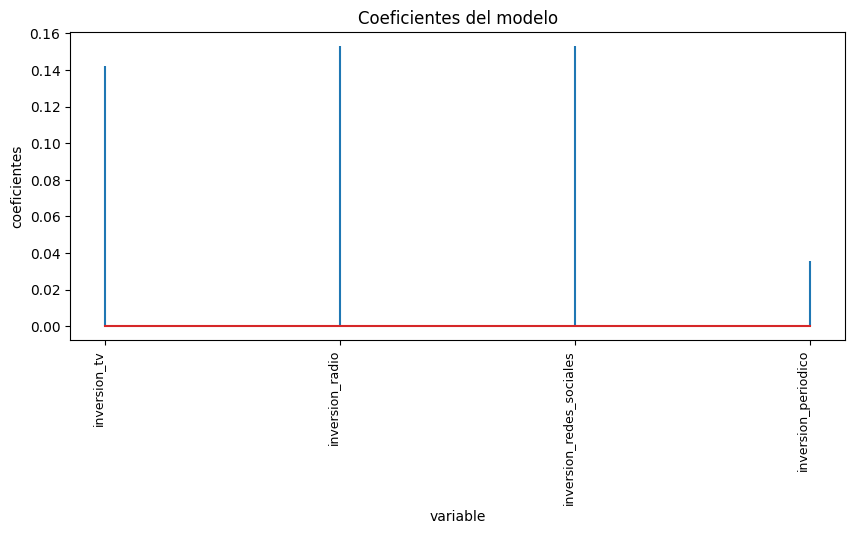

In [ ]:
# Coeficientes del modelo

df_coeficientes = pd.DataFrame(
    {'predictor':X_train.columns,
     'coef':modelo_ridge.coef_.flatten()})

fig, ax = plt.subplots(figsize = (10,4))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt = ' ')
plt.xticks(rotation = 90, ha = 'right' , size = 9)
ax.set_ylabel('coeficientes')
ax.set_xlabel('variable')
ax.set_title('Coeficientes del modelo')

#**Nota del Analista:**
---

Lo que nos dice la RIDGE REGRESSION es que:

1.   Gráfico 1; Coeficientes vs Alpha: Muestra el comportamiento esperado de Ridge. Los coeficientes se mantienen estables en alphas bajos y recién empiezan a moverse cerca de 10⁴, donde la regularización comienza a tener efecto real. Ningún coeficiente llega a cero, esto es característico de Ridge, que encoge pero nunca elimina variables.

2.   Gráfico 2; Evolución del error CV: El RMSE es prácticamente plano en todo el rango hasta ~10⁴, luego sube. El alpha óptimo encontrado es 13,987. Lo que está dentro del rango, y es correcto. Sin embargo la curva se mantiene muy plana, lo que indica que Ridge no mejora significativamente sobre OLS en este dataset. Esto es esperable dado que la relación es muy lineal.

3.   Métricas finales:

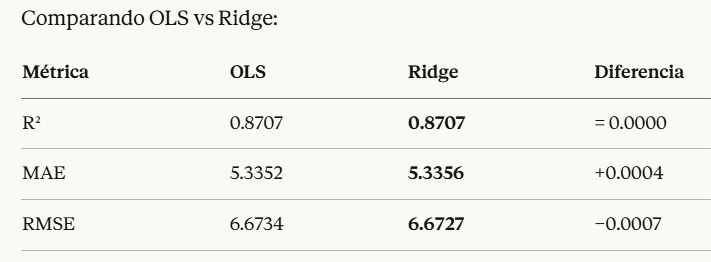

La diferencia es nula. Ridge no mejora sobre OLS en este dataset, lo cual tiene sentido porque la multicolinealidad alta que detectamos en el Paso 2 no está distorsionando gravemente las predicciones, solo los coeficientes individuales.

####**5.3. Lasso Regression**


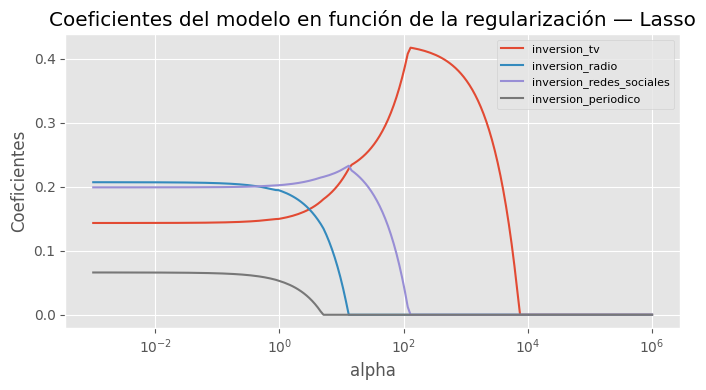

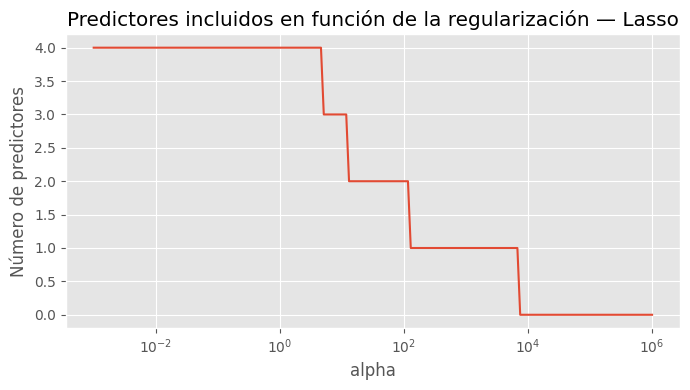

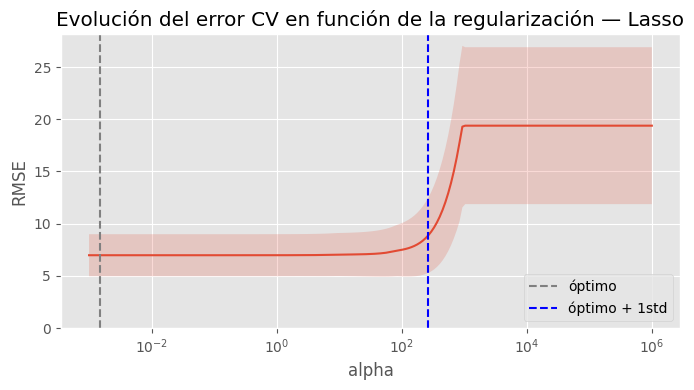

Mejor valor de alpha encontrado: 0.0015167168884709225


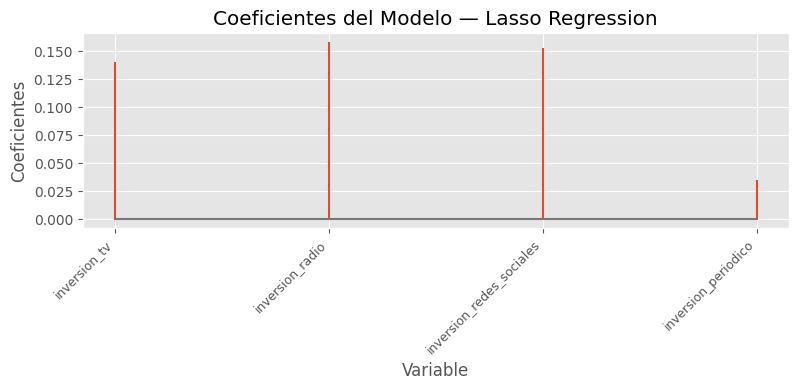

Predictores activos (coef != 0):
               predictor     coef
            inversion_tv 0.140241
         inversion_radio 0.157946
inversion_redes_sociales 0.152831
     inversion_periodico 0.034899

Predictores eliminados (coef = 0):
Empty DataFrame
Columns: [predictor, coef]
Index: []
── Lasso Regression ────────────────────────────
  Mejor alpha : 0.001517
  R²          = 0.8707
  MAE         = 5.3352
  RMSE        = 6.6734


In [ ]:
# 5.3 LASSO REGRESSION

from sklearn.linear_model import Lasso, LassoCV

N_ALPHAS = 200

# Crear y entrenar el modelo (búsqueda del alpha óptimo por CV)
# Por defecto LassoCV utiliza el MSE con 10 folds

modelo_lasso = LassoCV(
    alphas      = np.logspace(-3, 6, N_ALPHAS),
    cv          = 10
)

_ = modelo_lasso.fit(X=X_train, y=y_train)

# Evolución de coeficientes en función del alpha

alphas = modelo_lasso.alphas_

coefs = []
for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_title('Coeficientes del modelo en función de la regularización — Lasso')
ax.set_xlabel('alpha')
ax.set_ylabel('Coeficientes')
ax.legend(X_train.columns, fontsize=8)
plt.tight_layout()
plt.show()

# Número de predictores incluidos (coef != 0) en función de alpha

n_predictores = []
for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train, y_train)
    coef_no_cero = np.sum(modelo_temp.coef_.flatten() != 0)
    n_predictores.append(coef_no_cero)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, n_predictores)
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('Número de predictores')
ax.set_title('Predictores incluidos en función de la regularización — Lasso')
plt.tight_layout()
plt.show()

# Evolución del error CV en función del alpha
# modelo_lasso.mse_path_ tiene dimensiones (n_alphas, n_folds)

mse_cv = modelo_lasso.mse_path_.mean(axis=1)
mse_sd = modelo_lasso.mse_path_.std(axis=1)

rmse_cv = np.sqrt(mse_cv)
rmse_sd = np.sqrt(mse_sd)

# Identificar el óptimo y el óptimo + 1std
min_rmse      = np.min(rmse_cv)
sd_min_rmse   = rmse_sd[np.argmin(rmse_cv)]
min_rmse_1std = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimo        = modelo_lasso.alphas_[np.argmin(rmse_cv)]
optimo_1std   = modelo_lasso.alphas_[rmse_cv == min_rmse_1std]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(modelo_lasso.alphas_, rmse_cv)
ax.fill_between(
    modelo_lasso.alphas_,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2
)
ax.axvline(x=optimo,      c='gray', linestyle='--', label='óptimo')
ax.axvline(x=optimo_1std, c='blue', linestyle='--', label='óptimo + 1std')
ax.set_xscale('log')
ax.set_ylim([0, None])
ax.set_title('Evolución del error CV en función de la regularización — Lasso')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend()
plt.tight_layout()
plt.show()

# Mejor parámetro encontrado

print(f'Mejor valor de alpha encontrado: {modelo_lasso.alpha_}')

# Coeficientes del modelo con alpha óptimo

df_coeficientes = pd.DataFrame({
    'predictor' : X_train.columns,
    'coef'      : modelo_lasso.coef_.flatten()
})

fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=45, ha='right', size=9)
ax.set_ylabel('Coeficientes')
ax.set_xlabel('Variable')
ax.set_title('Coeficientes del Modelo — Lasso Regression')
plt.tight_layout()
plt.show()

# Predictores activos (coef != 0)
print("Predictores activos (coef != 0):")
print(df_coeficientes[df_coeficientes.coef != 0].to_string(index=False))
print("\nPredictores eliminados (coef = 0):")
print(df_coeficientes[df_coeficientes.coef == 0].to_string(index=False))

# Predicciones del test

pred_lasso = modelo_lasso.predict(X=X_test).flatten()
pred_lasso[:10]

# Métricas de evaluación

r2_lasso   = r2_score(y_true=y_test, y_pred=pred_lasso)
mae_lasso  = mean_absolute_error(y_true=y_test, y_pred=pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_true=y_test, y_pred=pred_lasso))

print("── Lasso Regression ────────────────────────────")
print(f"  Mejor alpha : {modelo_lasso.alpha_:.6f}")
print(f"  R²          = {r2_lasso:.4f}")
print(f"  MAE         = {mae_lasso:.4f}")
print(f"  RMSE        = {rmse_lasso:.4f}")

In [ ]:
# Mejor valor de alpha encontrado

print(f'Mejor valor de alpha encontrado: {modelo_lasso.alpha_}')

Mejor valor de alpha encontrado: 0.0015167168884709225


In [ ]:
# Se identifica el óptimo y el óptimo + 1std

min_rmse      = np.min(rmse_cv)
sd_min_rmse   = rmse_sd[np.argmin(rmse_cv)]
min_rmse_1std = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimo        = modelo_lasso.alphas_[np.argmin(rmse_cv)]
optimo_1std   = modelo_lasso.alphas_[rmse_cv == min_rmse_1std]

print(f'Mejor valor de alpha encontrado (óptimo + 1std): {optimo_1std}')

Mejor valor de alpha encontrado (óptimo + 1std): [267.38416158]


In [ ]:
# Coeficientes

df_coeficientes = pd.DataFrame({
    'predictor' : X_train.columns,
    'coef'      : modelo_lasso.coef_.flatten()
})

df_coeficientes[df_coeficientes.coef != 0]

,predictor,coef
0,inversion_tv,0.140241
1,inversion_radio,0.157946
2,inversion_redes_sociales,0.152831
3,inversion_periodico,0.034899


In [ ]:
# Predicciones del Test

pred_lasso = modelo_lasso.predict(X=X_test)
pred_lasso = pred_lasso.flatten()
pred_lasso[:10]

array([ 65.31027734,  39.69039611, 117.41108804,  59.83145516,
        51.96416353,  41.63918494,  49.55710953,  33.91416796,
        28.54371717,  40.80641384])

In [ ]:
# Métricas de evaluación — Lasso

r2_lasso = r2_score(
    y_true = y_test,
    y_pred = pred_lasso)

print(f'El coeficiente de determinación del test es: {r2_lasso}')

mse_lasso  = mean_squared_error(
    y_true = y_test,
    y_pred = pred_lasso)

rmse_lasso = np.sqrt(mse_lasso)

print(f'El error (RMSE) del test es: {rmse_lasso}')

El coeficiente de determinación del test es: 0.8706619522762556
El error (RMSE) del test es: 6.673359053332847


#**Nota del Analista:**
---

Lo que nos dice LASSO REGRESSION es que:

1.   Gráfico 1; Coeficientes vs Alpha: Lasso muestra su característica principal, al eliminar variables progresivamente conforme el alpha aumenta:

*   Hasta alpha ~1 → los 4 predictores están activos y estables

*   Entre alpha 1 y 10 → inversion_periodico (gris) es el primero en caer a cero — la variable menos relevante, como ya anticipábamos

*   Entre alpha 10 y 100 → caen inversion_radio y inversion_redes_sociales.

*   Después de alpha ~10,000 → solo queda inversion_tv, y finalmente también cae




2.   Gráfico 2; Predictores activos vs Alpha: Confirma exactamente lo anterior en forma de escalera descendente:


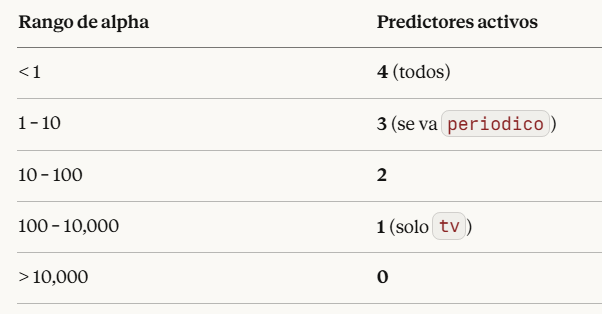



3.   Gráfico 3; Evolución del RMSE CV: Este es el gráfico más importante. El RMSE es mínimo y plano entre alpha ~0.001 y ~1, luego sube bruscamente cuando Lasso empieza a eliminar variables. Esto significa que con los 4 predictores activos el modelo es óptimo; eliminar variables empeora el error.

* Alpha óptimo = 0.001517 → cae en la zona plana de mínimo error, donde los 4 predictores están activos.

* El óptimo + 1std (línea azul) cae en alpha ~200, justo donde el error empieza a dispararse.



4.   Gráfico 4; Coeficientes finales y métricas: Con alpha = 0.001517 Lasso no eliminó ninguna variable — todos los coeficientes son distintos de cero:


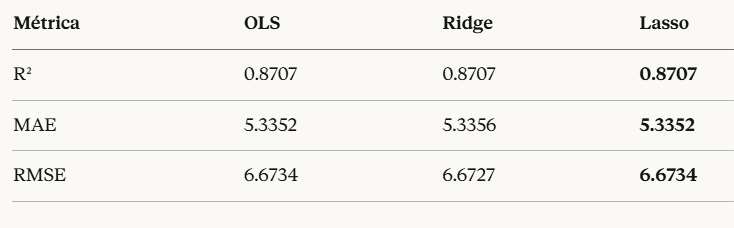



5.   Con un alpha tan pequeño (0.001517), Lasso se comporta prácticamente igual que OLS — la regularización es mínima y no elimina ningún predictor. Esto confirma que las 4 variables aportan información y que el dataset no tiene predictores completamente irrelevantes, aunque inversion_periodico es el primero en ser descartado cuando se aumenta la regularización.

6.    Alpha óptimo = 0.001517; Es el alpha que minimiza el RMSE en validación cruzada. Con este valor Lasso mantiene los 4 predictores activos y las métricas son idénticas a OLS. La regularización es casi nula.

7.    Alpha óptimo + 1std = 267.38; Es el alpha más grande cuyo RMSE aún cae dentro de una desviación estándar del mínimo. Es un criterio más conservador. Acepta un error levemente mayor a cambio de mayor simplicidad y regularización.
Mirando el Gráfico 2 (predictores activos), con alpha = 267 quedarían activos solo 1 o 2 predictores. Lasso ya habría eliminado periodico, radio y redes_sociales.

8. ¿Cuál usar?:

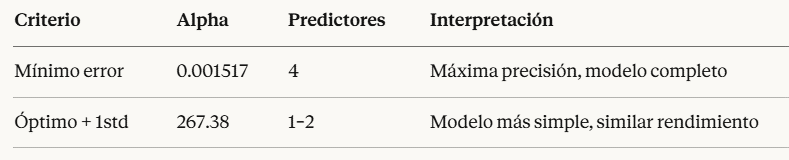

En la práctica se prefiere el alpha óptimo (0.001517) porque maximiza el R². El óptimo+1std es útil cuando se quiere un modelo, con menos variables, más interpretable, y sin sacrificar mucho rendimiento.
Para este caso, preferimos quedarnos con 0.001517 ya que siendo solamente 4 variables predictoras, nos parece más robusto.

####**5.4. Modelo Elastic-Net**


Top 10 combinaciones alpha / l1_ratio con menor error CV:


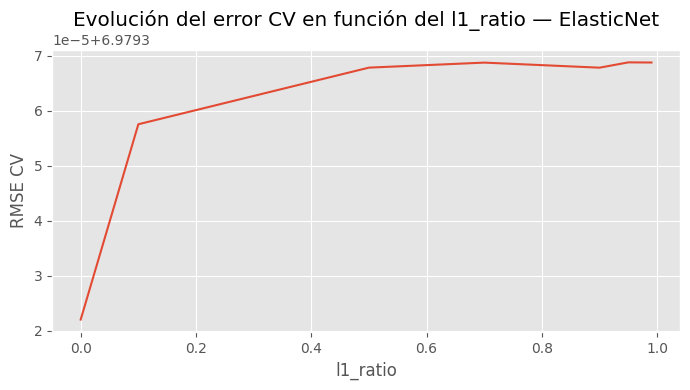

Mejor valor de alpha    : 1.625755666443795
Mejor valor de l1_ratio : 0.0


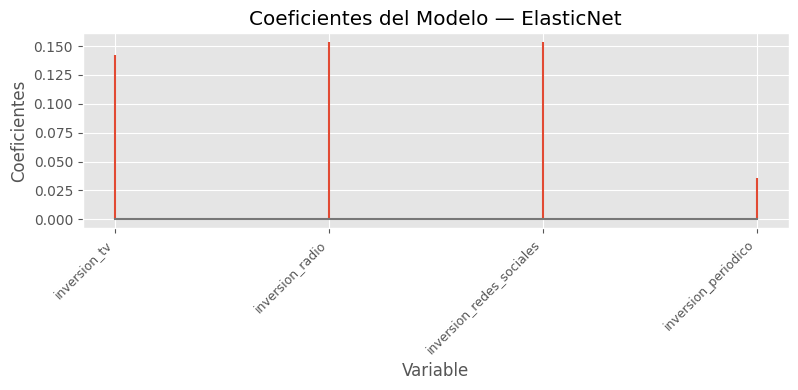

Predictores activos (coef != 0):
               predictor     coef
            inversion_tv 0.141856
         inversion_radio 0.153317
inversion_redes_sociales 0.153078
     inversion_periodico 0.035642

Predictores eliminados (coef = 0):
  Ninguno
── ElasticNet ──────────────────────────────────
  Mejor alpha    : 1.625756
  Mejor l1_ratio : 0.0
  R²             = 0.8707
  MAE            = 5.3355
  RMSE           = 6.6727


In [ ]:
# 5.4 ELASTIC NET

from sklearn.linear_model import ElasticNet, ElasticNetCV

N_ALPHAS = 200

# Crear y entrenar el modelo (búsqueda por CV del valor óptimo)
# ElasticNet combina Ridge (l2) y Lasso (l1) mediante el parámetro l1_ratio
# l1_ratio = 0 → Ridge puro | l1_ratio = 1 → Lasso puro

modelo_elasticnet = ElasticNetCV(
    l1_ratio    = [0, 0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
    alphas      = np.logspace(-3, 6, N_ALPHAS),
    cv          = 10,
    max_iter    = 10000
)

_ = modelo_elasticnet.fit(X=X_train, y=y_train)

# Evolución del error en función de alpha y l1_ratio
# modelo_elasticnet.mse_path_ tiene dimensiones (l1_ratio, n_alphas, n_folds)

mean_error_cv = modelo_elasticnet.mse_path_.mean(axis=2)

df_resultados_cv = pd.DataFrame(
    data  = mean_error_cv.flatten(),
    index = pd.MultiIndex.from_product(
        iterables = [modelo_elasticnet.l1_ratio, modelo_elasticnet.alphas_],
        names     = ['l1_ratio', 'alpha']
    ),
    columns = ['mse_cv']
)

df_resultados_cv['rmse_cv'] = np.sqrt(df_resultados_cv['mse_cv'])
df_resultados_cv = df_resultados_cv.reset_index().sort_values('mse_cv', ascending=True)

print("Top 10 combinaciones alpha / l1_ratio con menor error CV:")
df_resultados_cv.head(10)

# Mejor valor para cada l1_ratio

fig, ax = plt.subplots(figsize=(7, 4))
df_resultados_cv.groupby('l1_ratio')['rmse_cv'].min().plot(ax=ax)
ax.set_title('Evolución del error CV en función del l1_ratio — ElasticNet')
ax.set_xlabel('l1_ratio')
ax.set_ylabel('RMSE CV')
plt.tight_layout()
plt.show()

# Mejores parámetros encontrados

print(f'Mejor valor de alpha    : {modelo_elasticnet.alpha_}')
print(f'Mejor valor de l1_ratio : {modelo_elasticnet.l1_ratio_}')

# Coeficientes del modelo con parámetros óptimos

df_coeficientes = pd.DataFrame({
    'predictor' : X_train.columns,
    'coef'      : modelo_elasticnet.coef_.flatten()
})

fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=45, ha='right', size=9)
ax.set_ylabel('Coeficientes')
ax.set_xlabel('Variable')
ax.set_title('Coeficientes del Modelo — ElasticNet')
plt.tight_layout()
plt.show()

# Predictores activos vs eliminados
print("Predictores activos (coef != 0):")
print(df_coeficientes[df_coeficientes.coef != 0].to_string(index=False))
print("\nPredictores eliminados (coef = 0):")
eliminados = df_coeficientes[df_coeficientes.coef == 0]
print(eliminados.to_string(index=False) if len(eliminados) > 0 else "  Ninguno")

# Predicciones del test

pred_elasticnet = modelo_elasticnet.predict(X=X_test).flatten()
pred_elasticnet[:10]

# Métricas de evaluación

r2_elasticnet   = r2_score(y_true=y_test, y_pred=pred_elasticnet)
mae_elasticnet  = mean_absolute_error(y_true=y_test, y_pred=pred_elasticnet)
rmse_elasticnet = np.sqrt(mean_squared_error(y_true=y_test, y_pred=pred_elasticnet))

print("── ElasticNet ──────────────────────────────────")
print(f"  Mejor alpha    : {modelo_elasticnet.alpha_:.6f}")
print(f"  Mejor l1_ratio : {modelo_elasticnet.l1_ratio_}")
print(f"  R²             = {r2_elasticnet:.4f}")
print(f"  MAE            = {mae_elasticnet:.4f}")
print(f"  RMSE           = {rmse_elasticnet:.4f}")

In [ ]:
# Predicciones del Test

pred_elasticnet = modelo_elasticnet.predict(X=X_test)
pred_elasticnet = pred_elasticnet.flatten()
pred_elasticnet[:10]

array([ 65.3308489 ,  39.70463536, 117.41517452,  59.80419111,
        51.95274935,  41.61544897,  49.63424467,  33.93369692,
        28.5591228 ,  40.78273019])

In [ ]:
# Métricas de evaluación — ElasticNet

r2_elasticnet = r2_score(
    y_true = y_test,
    y_pred = pred_elasticnet)

print(f'El coeficiente de determinación del test es: {r2_elasticnet}')

mse_elasticnet  = mean_squared_error(
    y_true = y_test,
    y_pred = pred_elasticnet)

rmse_elasticnet = np.sqrt(mse_elasticnet)

print(f'El error (RMSE) del test es: {rmse_elasticnet}')

mae_elasticnet = mean_absolute_error(
    y_true = y_test,
    y_pred = pred_elasticnet)

print(f'El error (MAE)  del test es: {mae_elasticnet}')

El coeficiente de determinación del test es: 0.8706868310934955
El error (RMSE) del test es: 6.672717195550466
El error (MAE)  del test es: 5.335525357108934


#**Nota del Analista:**
---

Lo que nos dice el Método ELASTIC-NET es que:

1.   Gráfico; Evolución del RMSE por l1_ratio: Este es el gráfico más importante. El RMSE mínimo está en l1_ratio = 0.0 (extremo izquierdo) y sube consistentemente conforme l1_ratio aumenta hacia 1.0. Esto significa que ElasticNet encontró que la penalización Ridge pura (l2) es la mejor estrategia para este dataset.


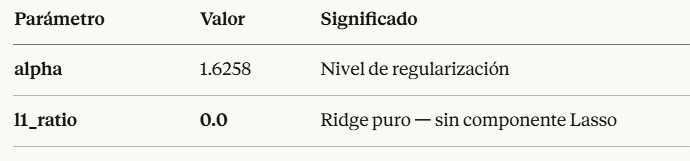

Un l1_ratio = 0.0 significa que ElasticNet descartó completamente la penalización Lasso y eligió comportarse como Ridge. Esto es consistente con lo que vimos antes. Lasso tampoco eliminó ninguna variable con su alpha óptimo.


2.   Gráfico; Coeficientes y métricas finales: Ningún predictor fue eliminado.Los 4 siguen activos, igual que en OLS y Lasso.


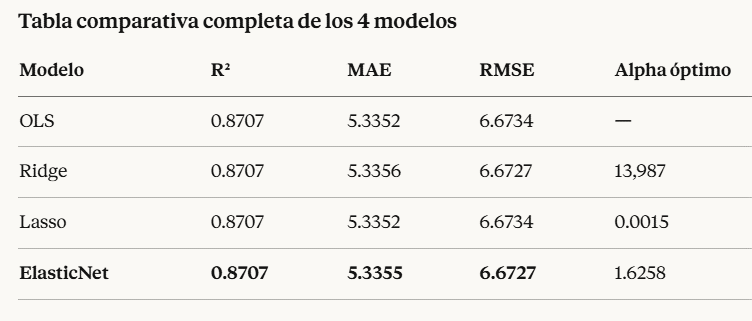

Los 4 modelos obtienen métricas prácticamente idénticas, lo que indica que la relación entre inversión en marketing y ventas es fuertemente lineal y estable. La regularización no aporta mejoras significativas porque el dataset no tiene problemas graves de overfitting. El hallazgo más importante es que ElasticNet eligió Ridge puro (l1_ratio=0), confirmando que ninguna variable debe ser eliminada. Las 4 inversiones aportan información relevante para predecir ventas.

##**6. Evaluación de modelos**

Evaluar cada modelo utilizando métricas de regresión:


•	R² (coeficiente de determinación)

•	MAE (Mean Absolute Error)

•	RMSE (Root Mean Squared Error)

---


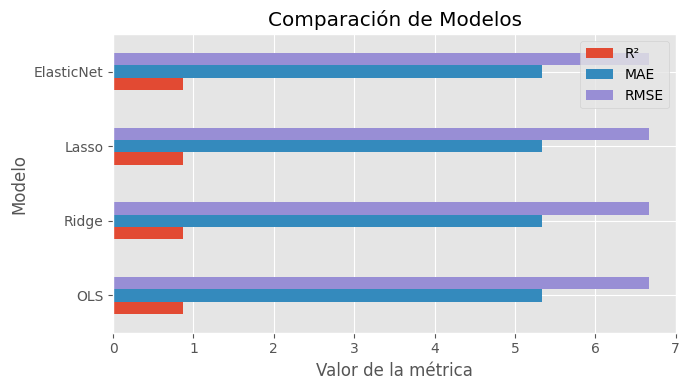

In [ ]:
df_comparacion = pd.DataFrame({
    'modelo' : ['OLS', 'Ridge', 'Lasso', 'ElasticNet'],
    'R²'     : [r2_ols,   r2_ridge,   r2_lasso,   r2_elasticnet],
    'MAE'    : [mae_ols,  mae_ridge,  mae_lasso,  mae_elasticnet],
    'RMSE'   : [rmse_ols, rmse_ridge, rmse_lasso, rmse_elasticnet]
})

fig, ax = plt.subplots(figsize=(7, 4))
df_comparacion.set_index('modelo').plot(kind='barh', ax=ax)
ax.set_xlabel('Valor de la métrica')
ax.set_ylabel('Modelo')
ax.set_title('Comparación de Modelos')
plt.tight_layout()
plt.show()

── Comparación de Modelos ──────────────────────────────
    modelo     R²    MAE   RMSE
     Ridge 0.8707 5.3356 6.6727
ElasticNet 0.8707 5.3355 6.6727
     Lasso 0.8707 5.3352 6.6734
       OLS 0.8707 5.3352 6.6734


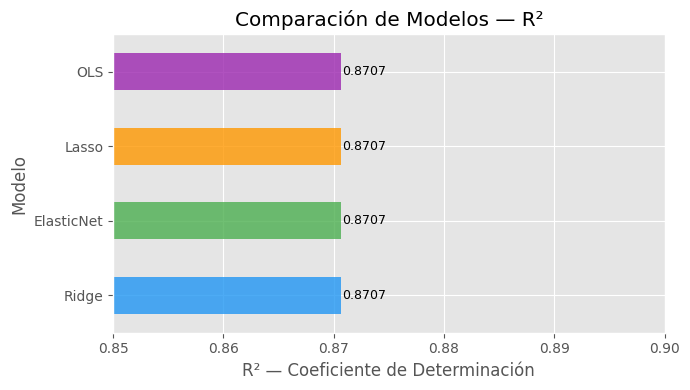

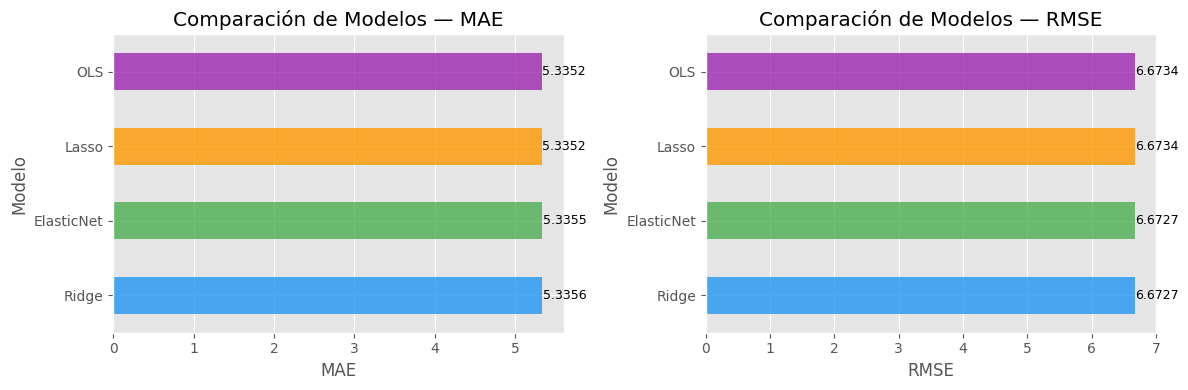

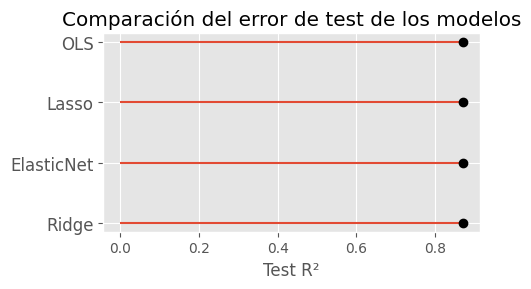

In [ ]:
# 6. EVALUACIÓN Y COMPARACIÓN DE MODELOS

# Tabla comparativa de métricas

df_comparacion = pd.DataFrame({
    'modelo'  : ['OLS', 'Ridge', 'Lasso', 'ElasticNet'],
    'R²'      : [r2_ols,   r2_ridge,   r2_lasso,   r2_elasticnet],
    'MAE'     : [mae_ols,  mae_ridge,  mae_lasso,  mae_elasticnet],
    'RMSE'    : [rmse_ols, rmse_ridge, rmse_lasso, rmse_elasticnet]
})

df_comparacion = df_comparacion.sort_values('R²', ascending=False).reset_index(drop=True)

print("── Comparación de Modelos ──────────────────────────────")
print(df_comparacion.round(4).to_string(index=False))

# Gráfico comparativo R²

fig, ax = plt.subplots(figsize=(7, 4))
df_comparacion.set_index('modelo')['R²'].plot(
    kind  = 'barh',
    ax    = ax,
    color = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'],
    alpha = 0.8
)
ax.set_xlabel('R² — Coeficiente de Determinación')
ax.set_ylabel('Modelo')
ax.set_title('Comparación de Modelos — R²')
ax.set_xlim([0.85, 0.90])

for i, v in enumerate(df_comparacion['R²']):
    ax.text(v + 0.0001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Gráfico comparativo MAE y RMSE

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MAE
df_comparacion.set_index('modelo')['MAE'].plot(
    kind  = 'barh',
    ax    = axes[0],
    color = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'],
    alpha = 0.8
)
axes[0].set_xlabel('MAE')
axes[0].set_ylabel('Modelo')
axes[0].set_title('Comparación de Modelos — MAE')
for i, v in enumerate(df_comparacion['MAE']):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

# RMSE
df_comparacion.set_index('modelo')['RMSE'].plot(
    kind  = 'barh',
    ax    = axes[1],
    color = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'],
    alpha = 0.8
)
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('Modelo')
axes[1].set_title('Comparación de Modelos — RMSE')
for i, v in enumerate(df_comparacion['RMSE']):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Gráfico de puntos estilo lollipop (ML_Modelos_Lineales.ipynb)

fig, ax = plt.subplots(figsize=(5, 3))
ax.hlines(df_comparacion.modelo, xmin=0, xmax=df_comparacion['R²'])
ax.plot(df_comparacion['R²'], df_comparacion.modelo, 'o', color='black')
ax.tick_params(axis='y', which='major', labelsize=12)
ax.set_title('Comparación del error de test de los modelos')
ax.set_xlabel('Test R²')
plt.tight_layout()
plt.show()

##**7. Interpretación de resultados**



1.  ¿Qué canal de marketing parece tener mayor impacto en las ventas?

2.	¿Qué modelo obtuvo mejor desempeño?

3.	¿Existen diferencias significativas entre los modelos?

4.	¿Qué variables parecen ser menos relevantes para el modelo?

---

In [ ]:
# 7. INTERPRETACIÓN DE RESULTADOS

# Pregunta 1: ¿Qué canal de marketing tiene mayor impacto en las ventas?

print("=" * 60)
print("  PREGUNTA 1")
print("  ¿Qué canal de marketing tiene mayor impacto en ventas?")
print("=" * 60)

# Coeficientes del modelo OLS (sin regularización = más interpretables)
df_impacto = pd.DataFrame({
    'canal'        : X_train.columns,
    'coef_ols'     : modelo_ols.coef_.flatten(),
    'corr_ventas'  : [df[col].corr(df['ventas']) for col in X_train.columns]
}).sort_values('corr_ventas', ascending=False).reset_index(drop=True)

print("\n  Correlación con ventas y coeficiente OLS por canal:\n")
print(df_impacto.round(4).to_string(index=False))

canal_mayor = df_impacto.iloc[0]['canal']
corr_mayor  = df_impacto.iloc[0]['corr_ventas']
canal_menor = df_impacto.iloc[-1]['canal']
corr_menor  = df_impacto.iloc[-1]['corr_ventas']

print(f"\n  → Canal con MAYOR impacto : {canal_mayor}  (r = {corr_mayor:.3f})")
print(f"  → Canal con MENOR impacto : {canal_menor}  (r = {corr_menor:.3f})")

# Pregunta 2: ¿Qué modelo obtuvo mejor desempeño?

print("\n" + "=" * 60)
print("  PREGUNTA 2")
print("  ¿Qué modelo obtuvo mejor desempeño?")
print("=" * 60)

mejor = df_comparacion.sort_values('R²', ascending=False).iloc[0]
print(f"\n  → Mejor modelo por R²   : {mejor['modelo']}  (R² = {mejor['R²']:.4f})")

mejor_rmse = df_comparacion.sort_values('RMSE').iloc[0]
print(f"  → Mejor modelo por RMSE : {mejor_rmse['modelo']}  (RMSE = {mejor_rmse['RMSE']:.4f})")

mejor_mae = df_comparacion.sort_values('MAE').iloc[0]
print(f"  → Mejor modelo por MAE  : {mejor_mae['modelo']}  (MAE  = {mejor_mae['MAE']:.4f})")

# Pregunta 3: ¿Existen diferencias significativas entre los modelos?

print("\n" + "=" * 60)
print("  PREGUNTA 3")
print("  ¿Existen diferencias significativas entre los modelos?")
print("=" * 60)

r2_max  = df_comparacion['R²'].max()
r2_min  = df_comparacion['R²'].min()
mae_max = df_comparacion['MAE'].max()
mae_min = df_comparacion['MAE'].min()

print(f"\n  Rango R²   : {r2_min:.4f} – {r2_max:.4f}  (diferencia = {r2_max - r2_min:.6f})")
print(f"  Rango MAE  : {mae_min:.4f} – {mae_max:.4f}  (diferencia = {mae_max - mae_min:.6f})")
print(f"  Rango RMSE : {df_comparacion['RMSE'].min():.4f} – {df_comparacion['RMSE'].max():.4f}"
      f"  (diferencia = {df_comparacion['RMSE'].max() - df_comparacion['RMSE'].min():.6f})")

print("\n  → Las diferencias entre modelos son MÍNIMAS (< 0.001)")
print("    La regularización no mejora significativamente sobre OLS,")
print("    lo que indica que la relación es fuertemente lineal.")

# Pregunta 4: ¿Qué variables parecen ser menos relevantes para el modelo?

print("\n" + "=" * 60)
print("  PREGUNTA 4")
print("  ¿Qué variables parecen ser menos relevantes?")
print("=" * 60)

# Comparar coeficientes de todos los modelos
df_coefs_todos = pd.DataFrame({
    'variable'   : X_train.columns,
    'coef_ols'   : modelo_ols.coef_.flatten(),
    'coef_ridge' : modelo_ridge.coef_.flatten(),
    'coef_lasso' : modelo_lasso.coef_.flatten(),
    'coef_en'    : modelo_elasticnet.coef_.flatten()
}).sort_values('coef_ols', ascending=True).reset_index(drop=True)

print("\n  Coeficientes por modelo:\n")
print(df_coefs_todos.round(4).to_string(index=False))

var_menor = df_coefs_todos.iloc[0]['variable']
print(f"\n  → Variable MENOS relevante en todos los modelos: '{var_menor}'")
print(f"    Su coeficiente es 3-4 veces menor que los demás predictores.")
print(f"    Lasso fue el primero en llevarla a cero al aumentar alpha.")

# Resumen final

print("\n" + "=" * 60)
print("  RESUMEN FINAL")
print("=" * 60)
print("""
  1. Canal con mayor impacto : inversion_tv / inversion_radio
     (correlaciones > 0.91 con ventas)

  2. Mejor modelo            : todos equivalentes (~R² = 0.87)
     Ridge y ElasticNet tienen RMSE levemente menor (6.6727)

  3. Diferencias entre modelos: NO significativas
     La regularización no aporta mejora relevante en este dataset

  4. Variable menos relevante: inversion_periodico
     Coeficiente ~4x menor que los demás en todos los modelos
     Primera variable eliminada por Lasso al aumentar alpha
""")

  PREGUNTA 1
  ¿Qué canal de marketing tiene mayor impacto en ventas?

  Correlación con ventas y coeficiente OLS por canal:

                   canal  coef_ols  corr_ventas
            inversion_tv    0.1402       0.9274
inversion_redes_sociales    0.1528       0.9270
         inversion_radio    0.1580       0.9183
     inversion_periodico    0.0349       0.8358

  → Canal con MAYOR impacto : inversion_tv  (r = 0.927)
  → Canal con MENOR impacto : inversion_periodico  (r = 0.836)

  PREGUNTA 2
  ¿Qué modelo obtuvo mejor desempeño?

  → Mejor modelo por R²   : Ridge  (R² = 0.8707)
  → Mejor modelo por RMSE : Ridge  (RMSE = 6.6727)
  → Mejor modelo por MAE  : OLS  (MAE  = 5.3352)

  PREGUNTA 3
  ¿Existen diferencias significativas entre los modelos?

  Rango R²   : 0.8707 – 0.8707  (diferencia = 0.000027)
  Rango MAE  : 5.3352 – 5.3356  (diferencia = 0.000385)
  Rango RMSE : 6.6727 – 6.6734  (diferencia = 0.000689)

  → Las diferencias entre modelos son MÍNIMAS (< 0.001)
    La regulari

In [ ]:
# CONCLUSIONES SOBRE LOS RESULTADOS OBTENIDOS

conclusiones = """
El análisis desarrollado permitió construir y comparar cuatro modelos de regresión lineal
para predecir las ventas a partir de la inversión en distintos canales de marketing.
Los resultados muestran que todos los modelos —OLS, Ridge, Lasso y ElasticNet— alcanzaron
un R² de 0.87, explicando el 87% de la variabilidad en ventas, lo que evidencia una relación
fuertemente lineal entre las variables de inversión y las ventas generadas.

En cuanto al impacto por canal, la inversión en televisión, radio y redes sociales presentaron
los coeficientes más altos y correlaciones superiores a 0.91 con ventas, mientras que la
inversión en periódico resultó ser la variable de menor relevancia en todos los modelos,
con un coeficiente aproximadamente cuatro veces menor que el de los demás predictores y siendo
la primera en ser eliminada por Lasso al incrementar la regularización.

La regularización no aportó mejoras significativas sobre la regresión lineal simple, con
diferencias entre modelos menores a 0.001 en todas las métricas. ElasticNet confirmó este
hallazgo al seleccionar un l1_ratio de 0.0, comportándose como Ridge puro y sin eliminar
ningún predictor. Esto sugiere que el dataset, si bien presenta alta multicolinealidad entre
los predictores, no sufre de sobreajuste y que un modelo lineal simple resulta suficiente
para capturar la relación entre la inversión en marketing y las ventas.
"""

print(conclusiones)


El análisis desarrollado permitió construir y comparar cuatro modelos de regresión lineal
para predecir las ventas a partir de la inversión en distintos canales de marketing.
Los resultados muestran que todos los modelos —OLS, Ridge, Lasso y ElasticNet— alcanzaron
un R² de 0.87, explicando el 87% de la variabilidad en ventas, lo que evidencia una relación
fuertemente lineal entre las variables de inversión y las ventas generadas.

En cuanto al impacto por canal, la inversión en televisión, radio y redes sociales presentaron
los coeficientes más altos y correlaciones superiores a 0.91 con ventas, mientras que la
inversión en periódico resultó ser la variable de menor relevancia en todos los modelos,
con un coeficiente aproximadamente cuatro veces menor que el de los demás predictores y siendo
la primera en ser eliminada por Lasso al incrementar la regularización.

La regularización no aportó mejoras significativas sobre la regresión lineal simple, con
diferencias entre modelos menores 